In [2]:
# this mini project is done for Supervised Learning Practice 
# PROJECT TITLE: Predicting Student Exam Performance
# GOAL IS TO PREDICT SCORES AND CLASSIFY PASS OR FAIL


In [3]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:

df = pd.read_csv('StudentsPerformance.csv')
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df = df.dropna()
print(len(df))
print(len(df.dropna()))

1000
1000


In [8]:
from sklearn.preprocessing import LabelEncoder
cat_cols = ['gender' , 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
le = LabelEncoder()
for cols in cat_cols:
    df[cols] = le.fit_transform(df[cols])

print(df)

     gender  race/ethnicity  parental level of education  lunch  \
0         0               1                            1      1   
1         0               2                            4      1   
2         0               1                            3      1   
3         1               0                            0      0   
4         1               2                            4      1   
..      ...             ...                          ...    ...   
995       0               4                            3      1   
996       1               2                            2      0   
997       0               2                            2      0   
998       0               3                            4      1   
999       0               3                            4      0   

     test preparation course  math score  reading score  writing score  
0                          1          72             72             74  
1                          0          69         

In [9]:
print(df['gender'].unique())
print(df['race/ethnicity'].unique())

[0 1]
[1 2 0 3 4]


In [10]:
from sklearn.preprocessing import StandardScaler
features = df.drop(columns = ['math score', 'reading score', 'writing score'])
y = df[['math score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print(X_scaled)

[[-0.96462528 -1.01504393 -0.81264039  0.74188112  0.74674788]
 [-0.96462528 -0.15044092  0.82795259  0.74188112 -1.33914006]
 [-0.96462528 -1.01504393  0.28108826  0.74188112  0.74674788]
 ...
 [-0.96462528 -0.15044092 -0.26577606 -1.34792485 -1.33914006]
 [-0.96462528  0.71416208  0.82795259  0.74188112 -1.33914006]
 [-0.96462528  0.71416208  0.82795259 -1.34792485  0.74674788]]


In [11]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.1)
X = selector.fit_transform(X_scaled)
print(X)

[[-0.96462528 -1.01504393 -0.81264039  0.74188112  0.74674788]
 [-0.96462528 -0.15044092  0.82795259  0.74188112 -1.33914006]
 [-0.96462528 -1.01504393  0.28108826  0.74188112  0.74674788]
 ...
 [-0.96462528 -0.15044092 -0.26577606 -1.34792485 -1.33914006]
 [-0.96462528  0.71416208  0.82795259  0.74188112 -1.33914006]
 [-0.96462528  0.71416208  0.82795259 -1.34792485  0.74674788]]


In [12]:
df['avg score'] = df[['math score' , 'reading score' , 'writing score']].mean(axis=1)
df['pass'] = df['avg score'].apply(lambda X : 1 if X>= 50 else 0)
y = df[['pass']] 

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.2, random_state= 42)


In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print(model.coef_)   
print(model.intercept_)  

[[-0.02780512  0.03144804 -0.00905426  0.05223586 -0.04158199]]
[0.90413015]


In [15]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
print("RMSE: ", mean_squared_error(y_test, y_pred, squared=False))
print("R2 score: ", r2_score(y_test, y_pred))

RMSE:  0.3350129945718353
R2 score:  0.038889261126195285


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [16]:
df['avg score'] = df[['math score' , 'reading score' , 'writing score']].mean(axis=1)
df['pass'] = df['avg score'].apply(lambda X : 1 if X>= 50 else 0)
y = df[['pass']] 

In [17]:
from sklearn.ensemble import RandomForestClassifier
clf  = RandomForestClassifier()
clf.fit(X_train, y_train.values.ravel()) # y_train could also be used 


RandomForestClassifier()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cfm = confusion_matrix(y_test, y_pred)
print(f"Confusion matrix is:  {cfm}")
print(f"Accuracy is:  {accuracy}")


Confusion matrix is:  [[  0  27]
 [  1 172]]
Accuracy is:  0.86


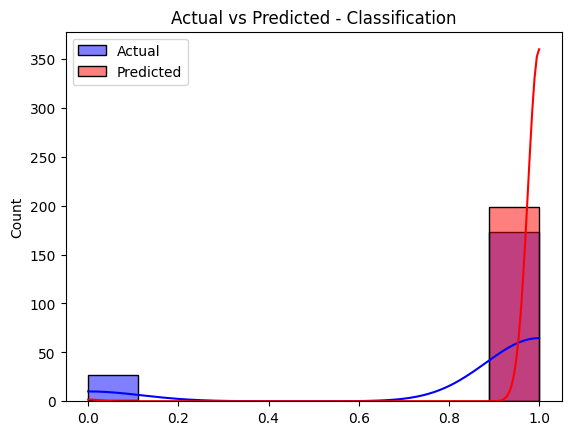

In [19]:
sns.histplot(y_test.values.flatten(), color='blue', label='Actual', kde=True)
sns.histplot(y_pred.flatten(), color='red', label='Predicted', kde=True)
plt.legend()
plt.title("Actual vs Predicted - Classification")
plt.show()

In [20]:
import pickle

# Save the trained classifier
with open('model.pkl', 'wb') as model_file:
    pickle.dump(clf, model_file)

# Save the scaler (used to normalize input)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
